In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [2]:
df = pd.read_csv("NIFTY50.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']]
data.dropna(inplace=True)

print(data.head())


            Close
Date             
2009-03-02  43.17
2009-03-03  43.89
2009-03-04  42.52
2009-03-05  41.49
2009-03-06  38.16


/var/folders/z4/58kf2rh54s395f0pkgk591q00000gn/T/ipykernel_1587/3643600502.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [4]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60
X, y = create_sequences(scaled_data, WINDOW_SIZE)

X = X.reshape((X.shape[0], X.shape[1], 1))


In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [6]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

model.summary()


/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0044 - val_loss: 2.4758e-04
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 1.9779e-04
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 1.7770e-04
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 2.2203e-04
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.9637e-04 - val_loss: 2.5500e-04
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.1589e-04 - val_loss: 1.5367e-04
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7876e-04 - val_loss: 1.6468e-04
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.1586e-04 - val_loss: 1.6316e-04
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.8070e-04 - val_loss: 1.8588e-04
Epoch 10/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.7451e-04 - val_loss: 1.7314e-04
Epoch 11/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7205e-04 - val_loss: 1.3579e-04


In [8]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [9]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 1.9864709490970105
MAE: 1.0450180782375238
R2 Score: 0.9605362071688729


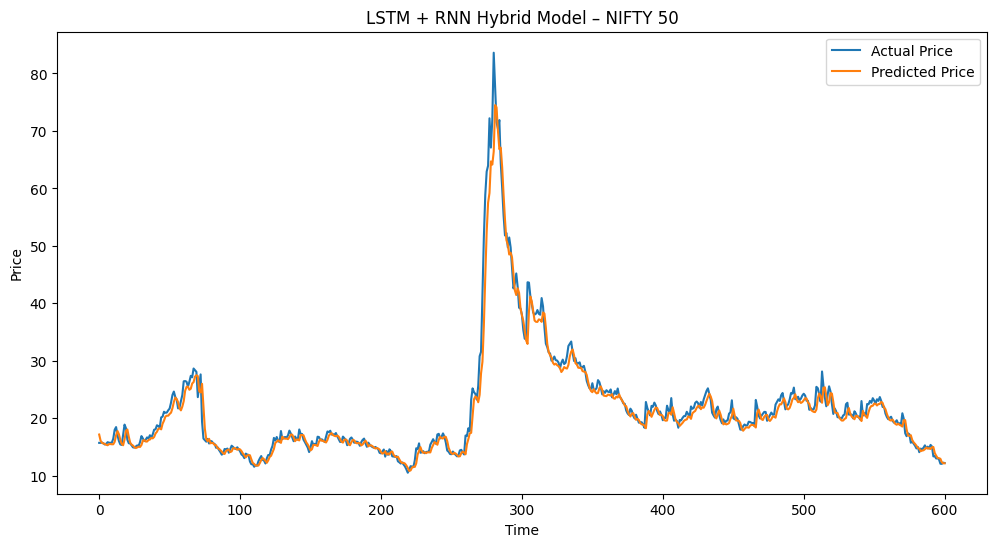

In [10]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("LSTM + RNN Hybrid Model – NIFTY 50")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()
